Calculate distances between all pairs of species

In [11]:
from Bio import Phylo
import numpy as np
#from scipy.spatial.distance import pdist, squareform

# Load phylogenetic tree
tree = Phylo.read(r"..\..\input\aligned_caffeine_tree.nwk", "newick")


# Extract terminal node names (species)
terminals = tree.get_terminals()
n = len(terminals)

# Initialize an empty distance matrix
phylo_distances = np.zeros((n, n))

# Compute pairwise distances
for i, sp1 in enumerate(terminals):
    for j, sp2 in enumerate(terminals):
        phylo_distances[i, j] = tree.distance(sp1, sp2)

# Optionally, print or convert the matrix to a DataFrame for better readability
import pandas as pd
species_names = [str(sp) for sp in terminals]
phylo_df = pd.DataFrame(phylo_distances, index=species_names, columns=species_names)
print(phylo_df)


                         C_bertrandii_A5  C_richardii_A575  \
C_bertrandii_A5                  0.00000           0.11234   
C_richardii_A575                 0.11234           0.00000   
C_farafanganensis_A208           0.12168           0.10018   
C_abbayesii_A601                 0.10538           0.08388   
C_millotii_A222                  0.11130           0.08980   
C_dolichophylla_A206             0.10885           0.08735   
C_ambodirianensis_A572           0.11243           0.09093   
C_homollei_A945                  0.11294           0.09846   
C_perrieri_A12                   0.12485           0.11037   
C_leroyi_A315                    0.11298           0.09850   
C_andrambovatensis_A310          0.13014           0.11566   
C_vianneyi_A946                  0.12294           0.10846   
C_resinosa_A8                    0.13048           0.11600   
C_arenesiana_A403                0.13797           0.12349   
C_kianjavatensis_A602            0.13772           0.12324   
C_vatova

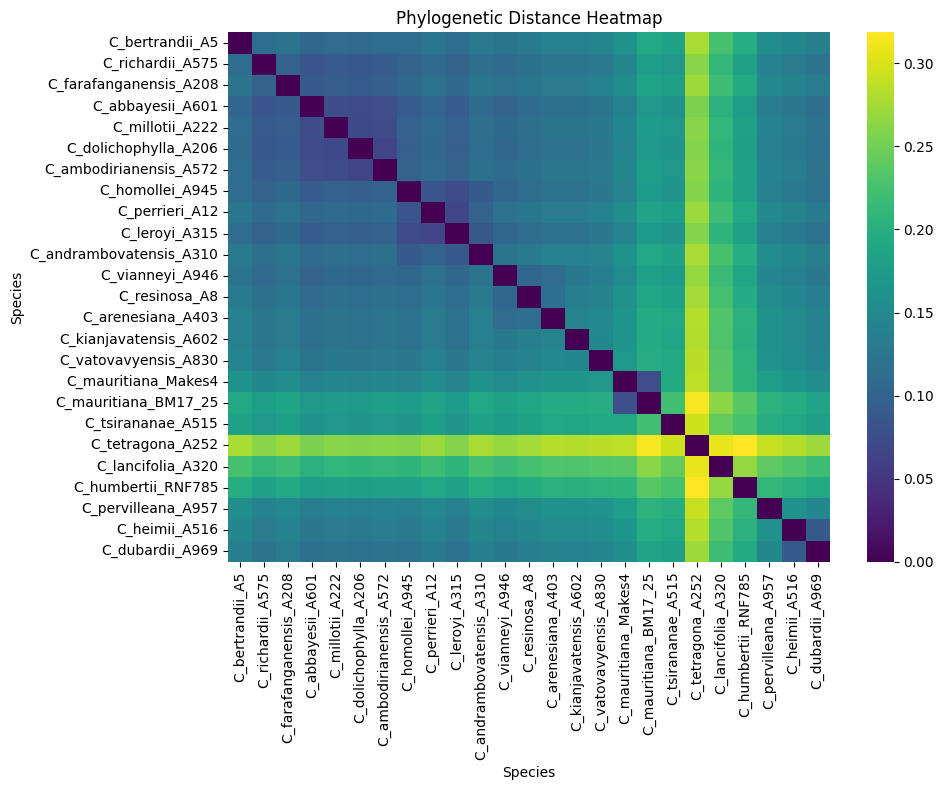

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(phylo_df, cmap="viridis", annot=False, xticklabels=True, yticklabels=True)
plt.title("Phylogenetic Distance Heatmap")
plt.xlabel("Species")
plt.ylabel("Species")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


C:\Users\adm1\AppData\Local\Temp\ipykernel_11812\258011153.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(phylo_distances, method="ward")


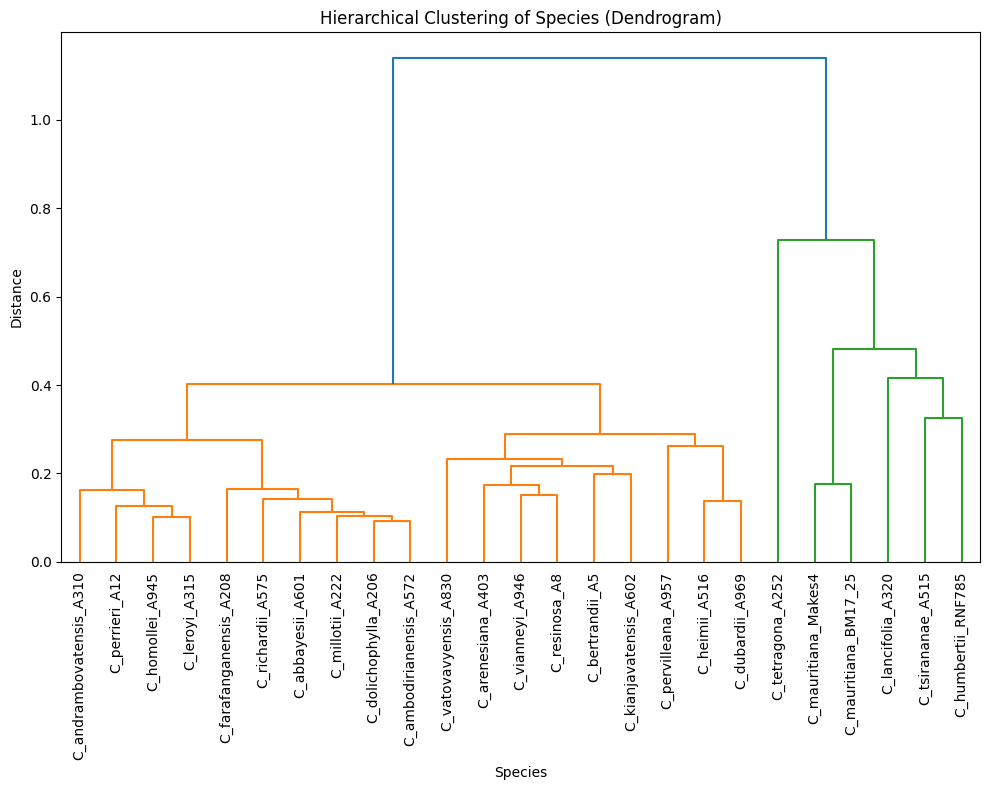

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
linkage_matrix = linkage(phylo_distances, method="ward")

# Plot dendrogram
plt.figure(figsize=(10, 8))
dendrogram(linkage_matrix, labels=species_names, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of Species (Dendrogram)")
plt.xlabel("Species")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


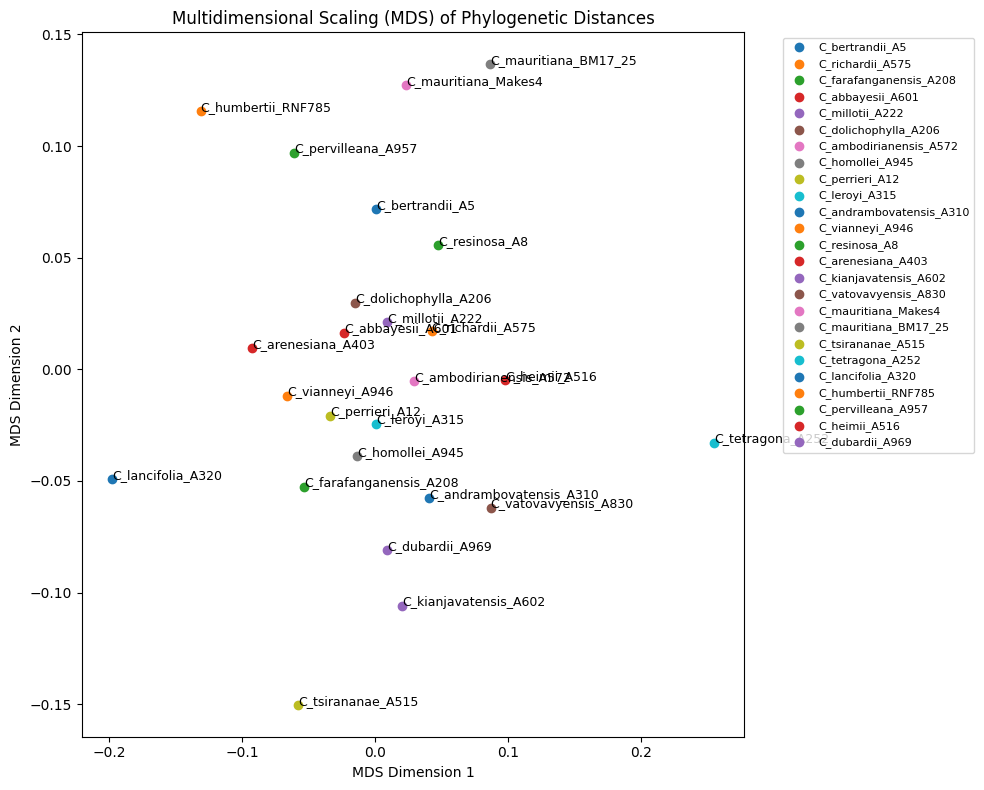

In [14]:
from sklearn.manifold import MDS

# Perform MDS to reduce distances to 2D
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(phylo_distances)

# Plot the MDS results
plt.figure(figsize=(10, 8))
for i, species in enumerate(species_names):
    plt.scatter(coords[i, 0], coords[i, 1], label=species)
    plt.text(coords[i, 0], coords[i, 1], species, fontsize=9)

plt.title("Multidimensional Scaling (MDS) of Phylogenetic Distances")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


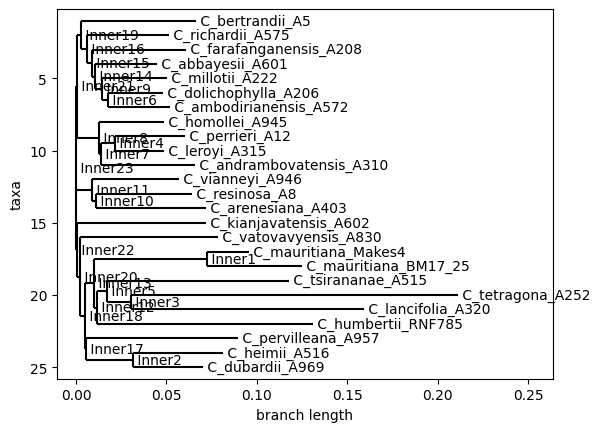

In [15]:
from Bio import Phylo

# Draw the tree
Phylo.draw(tree)


Calculate geographic distances between species locations

In [16]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic  # For Haversine-based distances

# Load CSV file
geo_df = pd.read_csv(r"..\input\gbif_mada_available_caff_content_formatted.csv")  # Replace with your file name
print(geo_df.head())  # Check the format of the loaded data




          specimen_id  longitude   latitude
0  C_humbertii_RNF785  43.797500 -22.875000
1         C_boinensis  46.801111 -16.319444
2         C_bissetiae  46.805278 -16.328889
3         C_bissetiae  46.432222 -15.588889
4         C_bissetiae  46.801111 -16.319444


Only one  geolocation point per species is necessary to calculate mantel test. Exercise to be done with median, mean, hand-picked


In [17]:
# Group by species and calculate median coordinates
median_coords = geo_df.groupby('specimen_id')[['longitude', 'latitude']].median().reset_index()
print(median_coords)


               specimen_id  longitude   latitude
0         C_abbayesii_A601  47.136667 -24.796389
1      C_ankaranensis_A525  48.629095 -16.801293
2        C_arenesiana_A403  47.896430 -19.029844
3        C_augagneuri_A966  47.863972 -21.382389
4          C_bertrandii_A5  46.674722 -25.122222
5              C_bissetiae  46.800000 -16.319444
6              C_boinensis  46.800000 -16.300000
7        C_boiviniana_A980  49.246820 -13.208889
8          C_bonnieri_A535  48.086940 -13.750000
9          C_dubardii_A969  49.166670 -12.578889
10  C_farafanganensis_A208  47.863972 -21.382500
11           C_heimii_A516  49.353050 -12.396327
12         C_homollei_A945  48.731110 -17.503889
13      C_humbertii_RNF785  44.136600 -23.078725
14         C_jumellei_A974  49.173610 -13.274722
15   C_kianjavatensis_A602  47.858610 -21.380280
16       C_labatii_APD3096  44.700833 -18.689444
17       C_lancifolia_A320  47.863972 -21.382389
18           C_leroyi_A315  49.285830 -14.336660
19         C_liaudii

KeyError: "['C_dolichophylla_A206', 'C_ambodirianensis_A572', 'C_andrambovatensis_A310', 'C_vatovavyensis_A830', 'C_mauritiana_Makes4', 'C_mauritiana_BM17_25'] not in index"

In [18]:
# Get species that are present in both phylo_df and median_coords
common_species = [species for species in species_names if species in median_coords['specimen_id'].values]

# Filter median_coords to only include rows with these species
aligned_coords = median_coords[median_coords['specimen_id'].isin(common_species)]

# Reorder aligned_coords to match the order of common_species
aligned_coords = aligned_coords.set_index('specimen_id').loc[common_species].reset_index()

# Verify alignment
print("Aligned Coordinates:")
print(aligned_coords)

# Ensure phylo_df and aligned_coords are in the same order
assert list(aligned_coords['specimen_id']) == common_species, "Alignment mismatch!"


Aligned Coordinates:
               specimen_id  longitude   latitude
0          C_bertrandii_A5  46.674722 -25.122222
1         C_richardii_A575  49.340278 -17.913889
2   C_farafanganensis_A208  47.863972 -21.382500
3         C_abbayesii_A601  47.136667 -24.796389
4          C_millotii_A222  48.318880 -19.014028
5          C_homollei_A945  48.731110 -17.503889
6           C_perrieri_A12  44.561944 -22.712917
7            C_leroyi_A315  49.285830 -14.336660
8          C_vianneyi_A946  47.865916 -21.380139
9            C_resinosa_A8  48.482222 -20.801944
10       C_arenesiana_A403  47.896430 -19.029844
11   C_kianjavatensis_A602  47.858610 -21.380280
12       C_tsirananae_A515  49.322797 -12.323889
13        C_tetragona_A252  47.865736 -18.032802
14       C_lancifolia_A320  47.863972 -21.382389
15      C_humbertii_RNF785  44.136600 -23.078725
16      C_pervilleana_A957  44.561389 -18.033559
17           C_heimii_A516  49.353050 -12.396327
18         C_dubardii_A969  49.166670 -12.578889

In [19]:
# Filter phylo_df to keep only rows/columns corresponding to species in common_species
phylo_df_filtered = phylo_df.loc[common_species, common_species]

# Ensure both phylo_df_filtered and aligned_coords are in the same order
aligned_coords = aligned_coords.set_index('specimen_id').loc[common_species].reset_index()

# Verify the alignment
assert list(aligned_coords['specimen_id']) == list(phylo_df_filtered.index), "Alignment mismatch between phylo_df and coordinates!"


In [32]:
# Prepare coordinates without aggregation
geo_coords = aligned_coords[['specimen_id', 'latitude', 'longitude']]

# Initialize an empty dataframe for distances
row_indices = geo_coords.index
geo_distances = pd.DataFrame(index=row_indices, columns=row_indices, dtype=float)

# Calculate pairwise distances
for i in row_indices:
    for j in row_indices:
        if i == j:
            geo_distances.loc[i, j] = 0
        elif pd.isna(geo_distances.loc[i, j]):
            coord1 = tuple(geo_coords.loc[i, ['latitude', 'longitude']])
            coord2 = tuple(geo_coords.loc[j, ['latitude', 'longitude']])
            distance = geodesic(coord1, coord2).kilometers
            geo_distances.loc[i, j] = distance
            geo_distances.loc[j, i] = distance

# Save or display results
print(geo_distances.head())
geo_distances.to_csv("../data/geographic_distances_full.csv")


           0           1           2           3           4           5   \
0    0.000000  835.500402  339.907971   30.906272  615.501105  641.971498   
1  835.500402    0.000000  495.754918  812.586550  221.168854  198.950603   
2  339.907971  495.754918    0.000000  317.926062  275.616779  302.619571   
3   30.906272  812.586550  317.926062    0.000000  593.369024  620.522715   
4  615.501105  221.168854  275.616779  593.369024    0.000000   32.996448   

           6           7           8           9           10          11  \
0  364.878884  965.152361  340.280741  454.970275  533.383869  340.042773   
1  627.687681  146.635123  495.382395  381.437184  313.978488  495.650303   
2  258.500544  625.970703    0.372772  117.996732  198.518066    0.730385   
3  363.853921  943.872973  318.297931  431.386008  513.548800  318.108046   
4  424.496432  351.344234  275.244091  165.282256   98.987288  275.471034   

            12          13          14          15          16           1

In [36]:
phylo_df_filtered.shape

(19, 19)

In [39]:
geo_distances.shape

(19, 19)

In [37]:
len(species)
species = phylo_df_filtered.index.tolist()   # now len(species) == 19


Performing Mantel test

In [38]:
from skbio.stats.distance import mantel
from skbio.stats.distance import DistanceMatrix

# Convert distance matrices to skbio DistanceMatrix objects
phylo_matrix = DistanceMatrix(phylo_df_filtered, ids=species)
geo_matrix = DistanceMatrix(geo_distances, ids=species)

# Perform the Mantel test
mantel_stat, p_value, _ = mantel(phylo_matrix, geo_matrix, method='pearson', permutations=999)

print(f"Mantel Statistic (r): {mantel_stat}")
print(f"P-value: {p_value}")


Mantel Statistic (r): 0.11371036331370056
P-value: 0.479


## Mantel statistic (r) = 0.1137

- This is essentially the Pearson correlation between the corresponding entries of your two distance matrices.

- An r of ~0.11 is very small—it indicates only a weak positive association.

## P-value = 0.479

- Under the null hypothesis of no association, the Mantel test permutes one matrix many times to build a null distribution of r.

- A p-value of 0.479 means that about 47.9% of those permuted datasets produced an r at least as large as 0.1137.

- Because this is far above the usual cutoff of 0.05, you fail to reject the null: there’s no statistically significant correlation between your two matrices.

## What it implies
- No strong link between the two distance measures you compared (for example, phylogenetic vs. geographic, or environmental vs. phylogenetic).

- Any slight positive r you observed could easily have arisen by chance.

- You’ll need either a stronger signal in your data, a different hypothesis (e.g. a partial Mantel controlling for a third matrix), or alternative methods if you want to detect subtler associations.

In [25]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

def mantel_test(matrix1, matrix2, permutations=999):
    """
    Perform Mantel test between two distance matrices.
    
    Args:
        matrix1 (np.ndarray): First distance matrix (square-form).
        matrix2 (np.ndarray): Second distance matrix (square-form).
        permutations (int): Number of permutations for significance testing.
    
    Returns:
        r (float): Mantel correlation coefficient.
        p-value (float): p-value from permutation test.
    """
    # Flatten the upper triangle of each matrix
    indices = np.triu_indices_from(matrix1, k=1)
    dist1 = matrix1[indices]
    dist2 = matrix2[indices]

    # Calculate Mantel correlation (Pearson's r)
    r, _ = pearsonr(dist1, dist2)

    # Perform permutations
    permuted_rs = []
    for _ in range(permutations):
        np.random.shuffle(dist2)
        permuted_r, _ = pearsonr(dist1, dist2)
        permuted_rs.append(permuted_r)

    # Calculate p-value
    permuted_rs = np.array(permuted_rs)
    p_value = np.sum(permuted_rs >= r) / permutations

    return r, p_value

# Example usage
phylo_matrix = phylo_df_filtered.to_numpy()  # Replace with your phylogenetic distance matrix
geo_matrix = geo_distances.to_numpy()   # Replace with your geographic distance matrix
r, p = mantel_test(phylo_matrix, geo_matrix)
print(f"r: {r}, p-value: {p}")


r: -0.02523114283621311, p-value: 0.6266266266266266


### Mantel statistic (r) = –0.0252
A correlation of –0.025 is essentially zero (very slight negative), indicating no meaningful tendency for distances in one matrix to increase or decrease in concert with distances in the other.

### P-value = 0.6266
Under permutation of one matrix, about 62.7% of the randomized r’s were as extreme (or more) than –0.025. This is nowhere near a conventional significance threshold (e.g. 0.05), so you fail to reject the null hypothesis of no association.

### Conclusion
- There is no evidence of either a positive or negative association between those two distance matrices.

- The small negative r can be dismissed as sampling noise.

- If you need to explore subtler relationships, consider:

    1. A partial Mantel (to control for a third distance matrix).

    2. Non-parametric alternatives like Procrustes analysis or multiple regression on distance matrices.

    3. Increasing your sample size or refining how distances are computed.

Mean coordinates

In [26]:
# Group by species and calculate mean coordinates
mean_coords = geo_df.groupby('specimen_id')[['longitude', 'latitude']].mean().reset_index()
print(mean_coords)

               specimen_id  longitude   latitude
0         C_abbayesii_A601  47.140570 -24.174610
1      C_ankaranensis_A525  48.629095 -16.801293
2        C_arenesiana_A403  47.895025 -19.590450
3        C_augagneuri_A966  47.863972 -21.382389
4          C_bertrandii_A5  46.876198 -24.312808
5              C_bissetiae  46.706455 -16.111182
6              C_boinensis  46.795880 -16.271885
7        C_boiviniana_A980  47.880575 -14.811397
8          C_bonnieri_A535  48.208530 -14.256892
9          C_dubardii_A969  48.340395 -14.031609
10  C_farafanganensis_A208  47.864843 -21.383352
11           C_heimii_A516  49.303806 -13.109262
12         C_homollei_A945  48.481000 -18.712502
13      C_humbertii_RNF785  44.415854 -23.323631
14         C_jumellei_A974  47.447478 -17.052145
15   C_kianjavatensis_A602  47.858610 -21.380280
16       C_labatii_APD3096  44.700833 -18.689444
17       C_lancifolia_A320  47.863972 -21.382389
18           C_leroyi_A315  49.130804 -15.858251
19         C_liaudii

In [27]:
# Get species that are present in both phylo_df and median_coords
common_species = [species for species in species_names if species in mean_coords['specimen_id'].values]

# Filter median_coords to only include rows with these species
aligned_coords = mean_coords[mean_coords['specimen_id'].isin(common_species)]

# Reorder aligned_coords to match the order of common_species
aligned_coords = aligned_coords.set_index('specimen_id').loc[common_species].reset_index()

# Verify alignment
print("Aligned Coordinates:")
print(aligned_coords)

# Ensure phylo_df and aligned_coords are in the same order
assert list(aligned_coords['specimen_id']) == common_species, "Alignment mismatch!"

Aligned Coordinates:
               specimen_id  longitude   latitude
0          C_bertrandii_A5  46.876198 -24.312808
1         C_richardii_A575  49.417086 -17.154198
2   C_farafanganensis_A208  47.864843 -21.383352
3         C_abbayesii_A601  47.140570 -24.174610
4          C_millotii_A222  48.593551 -18.990673
5          C_homollei_A945  48.481000 -18.712502
6           C_perrieri_A12  45.373314 -21.326863
7            C_leroyi_A315  49.130804 -15.858251
8          C_vianneyi_A946  47.865916 -21.380139
9            C_resinosa_A8  48.464596 -20.478723
10       C_arenesiana_A403  47.895025 -19.590450
11   C_kianjavatensis_A602  47.858610 -21.380280
12       C_tsirananae_A515  49.267763 -12.509111
13        C_tetragona_A252  46.422482 -16.405656
14       C_lancifolia_A320  47.863972 -21.382389
15      C_humbertii_RNF785  44.415854 -23.323631
16      C_pervilleana_A957  45.670411 -16.948101
17           C_heimii_A516  49.303806 -13.109262
18         C_dubardii_A969  48.340395 -14.031609

In [28]:
# Prepare coordinates without aggregation
geo_coords = aligned_coords[['specimen_id', 'latitude', 'longitude']]

# Initialize an empty dataframe for distances
row_indices = geo_coords.index
geo_distances = pd.DataFrame(index=row_indices, columns=row_indices, dtype=float)

# Calculate pairwise distances
for i in row_indices:
    for j in row_indices:
        if i == j:
            geo_distances.loc[i, j] = 0
        elif pd.isna(geo_distances.loc[i, j]):
            coord1 = tuple(geo_coords.loc[i, ['latitude', 'longitude']])
            coord2 = tuple(geo_coords.loc[j, ['latitude', 'longitude']])
            distance = geodesic(coord1, coord2).kilometers
            geo_distances.loc[i, j] = distance
            geo_distances.loc[j, i] = distance

# Save or display results
print(geo_distances.head())


           0           1           2           3           4           5   \
0    0.000000  835.500402  339.907971   30.906272  615.501105  641.971498   
1  835.500402    0.000000  495.754918  812.586550  221.168854  198.950603   
2  339.907971  495.754918    0.000000  317.926062  275.616779  302.619571   
3   30.906272  812.586550  317.926062    0.000000  593.369024  620.522715   
4  615.501105  221.168854  275.616779  593.369024    0.000000   32.996448   

           6           7           8           9           10          11  \
0  364.878884  965.152361  340.280741  454.970275  533.383869  340.042773   
1  627.687681  146.635123  495.382395  381.437184  313.978488  495.650303   
2  258.500544  625.970703    0.372772  117.996732  198.518066    0.730385   
3  363.853921  943.872973  318.297931  431.386008  513.548800  318.108046   
4  424.496432  351.344234  275.244091  165.282256   98.987288  275.471034   

            12          13          14          15          16           1

In [29]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

def mantel_test(matrix1, matrix2, permutations=999):
    """
    Perform Mantel test between two distance matrices.
    
    Args:
        matrix1 (np.ndarray): First distance matrix (square-form).
        matrix2 (np.ndarray): Second distance matrix (square-form).
        permutations (int): Number of permutations for significance testing.
    
    Returns:
        r (float): Mantel correlation coefficient.
        p-value (float): p-value from permutation test.
    """
    # Flatten the upper triangle of each matrix
    indices = np.triu_indices_from(matrix1, k=1)
    dist1 = matrix1[indices]
    dist2 = matrix2[indices]

    # Calculate Mantel correlation (Pearson's r)
    r, _ = pearsonr(dist1, dist2)

    # Perform permutations
    permuted_rs = []
    for _ in range(permutations):
        np.random.shuffle(dist2)
        permuted_r, _ = pearsonr(dist1, dist2)
        permuted_rs.append(permuted_r)

    # Calculate p-value
    permuted_rs = np.array(permuted_rs)
    p_value = np.sum(permuted_rs >= r) / permutations

    return r, p_value

# Example usage
phylo_matrix = phylo_df_filtered.to_numpy()  # Replace with your phylogenetic distance matrix
geo_matrix = geo_distances.to_numpy()   # Replace with your geographic distance matrix
r, p = mantel_test(phylo_matrix, geo_matrix)
print(f"r: {r}, p-value: {p}")


r: 0.11371036331370057, p-value: 0.07307307307307308


Here you have a small positive Mantel r≈0.114 but a p-value of about 0.073:

### Magnitude of r :
r=0.1137 again indicates only a weak positive association between the paired entries of your two distance matrices.

### Statistical significance (p = 0.0731):

- Under the usual α=0.05 threshold, you still fail to reject the null of no association, since 0.0731 > 0.05.

- However, this p-value is noticeably lower than in your previous tests (0.479, 0.627). It suggests a marginal trend that might become significant with more data or a more powerful test.

### What you can take from this
Not conventionally significant, but a hint of structure:
Something in your data may be driving a weak positive relationship, even though random permutations produce an equal or larger r about 7.3% of the time.

- Next steps if you want to probe further:

    1. Increase permutation count (e.g. from 999 to 9999) for a more precise p-value.

    2. Collect more samples (distance pairs), which will tighten your null distribution and could push this into significance.

    3. Use a partial Mantel, controlling for a third matrix, to isolate confounding effects.

    4. Explore alternative methods (e.g. Procrustes, multiple regression on distance matrices) to see if a more targeted test finds the same trend.

Bottom line Although r=0.114 hints at a weak positive link, p=0.073 is above 0.05, so you cannot claim a statistically significant association at the conventional level—but it’s close enough to warrant further investigation.

Trying Procrustes

In [40]:
from scipy.spatial import procrustes

# X and Y are (n × p) numpy arrays
mtx1, mtx2, disparity = procrustes(phylo_df_filtered, geo_distances)
print("Procrustes m² (disparity):", disparity)

Procrustes m² (disparity): 0.8546591493708723


A Procrustes disparity ( m² ) of 0.8547 tells you that, after optimally translating, rotating (and scaling) one configuration to match the other, you still have a very large residual sum‐of‐squares:

Range of m² in SciPy’s procrustes
Because SciPy first scales both matrices to unit “size” (sum of squared entries = 1), the disparity always lies between 0 (perfect fit) and 1 (no shared structure).

Interpretation of 0.8547

Very poor alignment: Only about 1 − 0.8547 = 0.1453 (≈ 14.5 %) of the variance in one configuration can be explained by the other.

The two ordinations/distances you’re comparing share little common pattern.

In [30]:
import matplotlib.pyplot as plt

# Flatten matrices for scatterplot
phylo_dist_flat = phylo_matrix[np.triu_indices(len(species), k=1)]
geo_dist_flat = geo_distances[np.triu_indices(len(species), k=1)]

# Plot
plt.scatter(geo_dist_flat, phylo_dist_flat, alpha=0.7)
plt.xlabel("Geographic Distance (km)")
plt.ylabel("Phylogenetic Distance")
plt.title("Correlation Between Geographic and Phylogenetic Distances")
plt.show()


KeyError: (array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9, 10, 10, 10, 10, 11, 11, 11,
       12, 12, 13]), array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,  2,  3,  4,
        5,  6,  7,  8,  9, 10, 11, 12, 13, 14,  3,  4,  5,  6,  7,  8,  9,
       10, 11, 12, 13, 14,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,  5,
        6,  7,  8,  9, 10, 11, 12, 13, 14,  6,  7,  8,  9, 10, 11, 12, 13,
       14,  7,  8,  9, 10, 11, 12, 13, 14,  8,  9, 10, 11, 12, 13, 14,  9,
       10, 11, 12, 13, 14, 10, 11, 12, 13, 14, 11, 12, 13, 14, 12, 13, 14,
       13, 14, 14]))